In [1]:
from scipy.io import readsav
import numpy as np
import matplotlib.pyplot as plt
import phasepack
from scipy.stats import gaussian_kde
from tqdm.notebook import tqdm
import image as img
from scipy import stats
%matplotlib inline

In [4]:
results = readsav("E:\IDL/nuwt/nuwt_fft_peaks.sav")
fft_peaks = results['nuwt_fft_peaks']
peak_data = fft_peaks['_SR_PTR'][0]
peak_data[0].dtype.names

('ANALYSIS_METHOD',
 'PEAK_POWER',
 'ERR_PEAK_POWER',
 'POWER_UNITS',
 'POWER_TO_PXLS',
 'PEAK_AMPLITUDE',
 'ERR_PEAK_AMPLITUDE',
 'AMP_UNITS',
 'AMP_TO_PXLS',
 'PEAK_FREQ',
 'FREQ_UNITS',
 'FREQ_TO_TIMESTEPS',
 'PEAK_VEL_AMP',
 'VEL_AMP_UNITS',
 'PEAK_PHASE',
 'ERR_PEAK_PHASE',
 'PEAK_BIN',
 'ADJACENT_PEAKS',
 'NUM_SIGNIF_PEAKS',
 'NUM_SAVED_WAVES',
 'SIGNIF_LEVEL',
 'KS_STAT',
 'KS_PROB',
 'AD_STAT',
 'AD_CRIT',
 'LB_STAT',
 'LB_CHISQRD',
 'ENBW',
 'USER_QUAL_FLAG',
 'AUTO_QUAL_FLAG')

In [11]:
def log_norm(data, x):
    length = data.shape[0]
    mu = np.mean(np.log(data))
    sigma = np.std(np.log(data))*np.sqrt(length/(length-1))
    return 1/(x*sigma*np.sqrt(2*np.pi))*np.exp(-0.5*(np.log(x)-mu)**2/sigma**2)

def confidence_interval_mu(data, confidence=0.95):
    length = data.shape[0]
    mu = np.mean(np.log(data))
    sigma = np.std(np.log(data))*np.sqrt(length/(length-1))
    t_score = stats.t.ppf((1 + confidence) / 2, df=length-1)
    return np.exp(mu), np.exp(mu-t_score*sigma/np.sqrt(length)), np.exp(mu+t_score*sigma/np.sqrt(length))

def confidence_interval_sigma(data, confidence=0.95):
    length = data.shape[0]
    w = np.std(np.log(data))**2 * length
    down = stats.chi2.ppf(q=(1-confidence)/2, df=length-1)
    up = stats.chi2.ppf(q=(1+confidence)/2, df=length-1)
    return np.exp(np.std(np.log(data))*np.sqrt(length/(length-1))), np.exp(np.sqrt(w/up)), np.exp(np.sqrt(w/down))

def anderson_test(data):
    anderson_result = stats.anderson(np.log(data), dist='norm')
    if anderson_result.statistic < anderson_result.critical_values[2]:
        return 1
    else:
        return 0


def draw_st(ax, data, title):
    im = ax.imshow(data, cmap='gray', origin='lower')
    # plt.colorbar(im, ax=ax)
    ax.set_aspect('auto')
    ax.set_xlabel('degree')
    ax.set_ylabel('time(min)')
    ax.set_title(title)
    ax.set_aspect('equal')
    return im

In [12]:
amp = []
period = []
vel_amp = []

amp_ave = []
period_ave = []
vel_amp_ave = []

amp_left = []
amp_right = []

period_left = []
period_right = []

vel_amp_left = []
vel_amp_right = []

for i in range(16):
    amp_data = np.stack(peak_data[i]['PEAK_AMPLITUDE'])[:, 0]
    amp_data = amp_data[amp_data > 0]
    freq_data = np.stack(peak_data[i]['PEAK_FREQ'])[:, 0]
    period_data = 1/freq_data[freq_data > 0]
    vel_amp_data = np.stack(peak_data[i]['PEAK_VEL_AMP'])[:, 0]
    vel_amp_data = vel_amp_data[vel_amp_data > 0]

    amp.append(amp_data)
    period.append(period_data)
    vel_amp.append(vel_amp_data)

    amp_mu, amp_mu_left, amp_mu_right = confidence_interval_mu(amp_data)
    period_mu, period_mu_left, period_mu_right = confidence_interval_mu(period_data)
    vel_amp_mu, vel_amp_mu_left, vel_amp_mu_right = confidence_interval_mu(vel_amp_data)

    amp_ave.append(amp_mu)
    amp_left.append(amp_mu_left)
    amp_right.append(amp_mu_right)

    period_ave.append(period_mu)
    period_left.append(period_mu_left)
    period_right.append(period_mu_right)

    vel_amp_ave.append(vel_amp_mu)
    vel_amp_left.append(vel_amp_mu_left)
    vel_amp_right.append(vel_amp_mu_right)

amp_ave = np.insert(np.array(amp_ave), 2, np.nan)
amp_left = np.insert(np.array(amp_left), 2, np.nan)
amp_right = np.insert(np.array(amp_right), 2, np.nan)

period_ave = np.insert(np.array(period_ave), 2, np.nan)
period_left = np.insert(np.array(period_left), 2, np.nan)
period_right = np.insert(np.array(period_right), 2, np.nan)

vel_amp_ave = np.insert(np.array(vel_amp_ave), 2, np.nan)
vel_amp_left = np.insert(np.array(vel_amp_left), 2, np.nan)
vel_amp_right = np.insert(np.array(vel_amp_right), 2, np.nan)

## 位移振幅统计

In [13]:
height = np.arange(7, 15.5, 0.5)
height = height[height!=8]

with plt.ioff():
    fig, ax = plt.subplots(figsize=(8, 4))

    for i in tqdm(range(16), total=16):
        mu, left_mu, right_mu = confidence_interval_mu(amp[i])
        sigma, left_sigma, right_sigma = confidence_interval_sigma(amp[i])
        text = f'mu: [{left_mu:.2f}, {mu:.2f}, {right_mu:.2f}]\nsigma: [{sigma:.2f}, {left_sigma:.2f}, {right_sigma:.2f}]\nanderson test: {anderson_test(amp[i])}'

        x = np.linspace(12.5, 700, 200)
        y = log_norm(amp[i], x)*amp[i].shape[0]*25
        ax.plot(x, y, 'k')
        n, bins, patches = ax.hist(amp[i], bins=np.arange(0, 715, 25), edgecolor='black')
        ax.set_xlabel('Displacement Amplitude / km')
        ax.set_ylabel('number of waves')
        ax.set_xlim(0, 700)
        ax.set_ylim(0, 55)

        ax.text(450, 40, text)
        ax.set_title(f'Displacement Amplitude at {height[i]:.1f}Mm')
        fig.savefig(f'./fig/位移振幅/{height[i]:.1f}Mm.png', dpi=300)
        ax.clear()
img.images_to_gif('./fig/位移振幅/', './fig/振幅统计.gif', fps=2)

  0%|          | 0/16 [00:00<?, ?it/s]

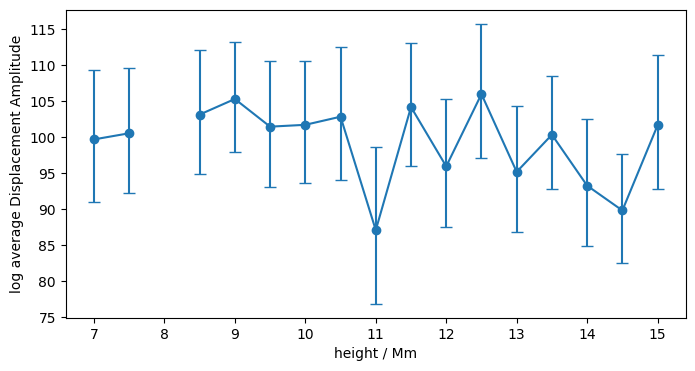

In [14]:
plt.close()
fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(np.arange(7, 15.5, 0.5), amp_ave, yerr=[amp_ave-amp_left, amp_right-amp_ave], fmt='o-', capsize=4)
ax.set_xlabel('height / Mm')
ax.set_ylabel('log average Displacement Amplitude')
fig.savefig('./fig/位移振幅对数均值.png', dpi=300)

## 周期统计

In [15]:
with plt.ioff():
    fig, ax = plt.subplots(figsize=(8, 4))

    for i in tqdm(range(16), total=16):
        mu, left_mu, right_mu = confidence_interval_mu(period[i])
        sigma, left_sigma, right_sigma = confidence_interval_sigma(period[i])
        text = f'mu: [{left_mu:.2f}, {mu:.2f}, {right_mu:.2f}]\nsigma: [{sigma:.2f}, {left_sigma:.2f}, {right_sigma:.2f}]\nanderson test: {anderson_test(period[i])}'

        x = np.linspace(12.5, 500, 200)
        y = log_norm(period[i], x)*period[i].shape[0]*25
        ax.plot(x, y, 'k')

        n, bins, patches = ax.hist(period[i], bins=np.arange(0, 525, 25), edgecolor='black')
        ax.set_xlabel('period / s')
        ax.set_ylabel('number of waves')
        ax.set_xlim(0, 500)
        ax.set_ylim(0, 100)

        ax.text(300, 85, text)
        ax.set_title(f'period at {height[i]:.1f}Mm')
        fig.savefig(f'./fig/周期/{height[i]:.1f}Mm.png', dpi=300)
        ax.clear()
img.images_to_gif('./fig/周期/', './fig/周期统计.gif', fps=2)

  0%|          | 0/16 [00:00<?, ?it/s]

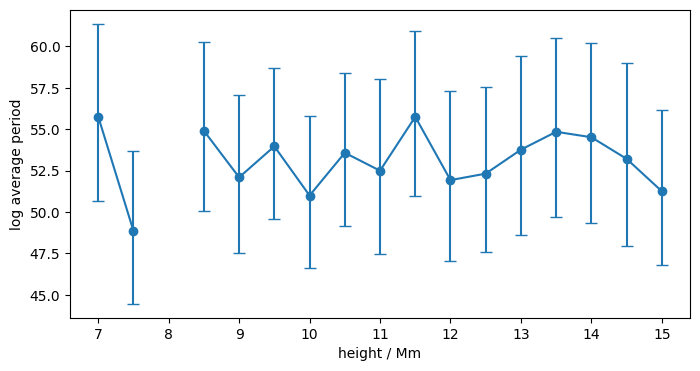

In [16]:
plt.close()
fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(np.arange(7, 15.5, 0.5), period_ave, yerr=[period_ave-period_left, period_right-period_ave], fmt='o-', capsize=4)
ax.set_xlabel('height / Mm')
ax.set_ylabel('log average period')
fig.savefig('./fig/周期对数均值.png', dpi=300)

## 速度振幅统计

In [17]:
with plt.ioff():
    fig, ax = plt.subplots(figsize=(8, 4))

    for i in tqdm(range(16), total=16):
        mu, left_mu, right_mu = confidence_interval_mu(vel_amp[i])
        sigma, left_sigma, right_sigma = confidence_interval_sigma(vel_amp[i])
        text = f'mu: [{left_mu:.2f}, {mu:.2f}, {right_mu:.2f}]\nsigma: [{sigma:.2f}, {left_sigma:.2f}, {right_sigma:.2f}]\nanderson test: {anderson_test(vel_amp[i])}'

        x = np.linspace(0.5, 120, 200)
        y = log_norm(vel_amp[i], x)*vel_amp[i].shape[0]
        ax.plot(x, y, 'k')
        n, bins, patches = ax.hist(vel_amp[i], bins=np.arange(0, 121, 1), edgecolor='black')
        ax.set_xlabel('Velocity Amplitude / km')
        ax.set_ylabel('number of waves')
        ax.set_xlim(0, 120)
        ax.set_ylim(0, 25)

        ax.text(80, 20, text)
        ax.set_title(f'Velocity Amplitude at {height[i]:.1f}Mm')
        fig.savefig(f'./fig/速度振幅/{height[i]:.1f}Mm.png', dpi=300)
        ax.clear()
img.images_to_gif('./fig/速度振幅/', './fig/速度振幅统计.gif', fps=2)

  0%|          | 0/16 [00:00<?, ?it/s]

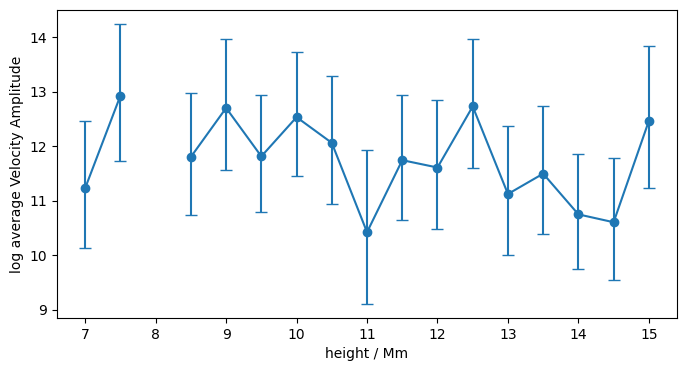

In [18]:
plt.close()
fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(np.arange(7, 15.5, 0.5), vel_amp_ave, yerr=[vel_amp_ave-vel_amp_left, vel_amp_right-vel_amp_ave], fmt='o-', capsize=4)
ax.set_xlabel('height / Mm')
ax.set_ylabel('log average Velocity Amplitude')
fig.savefig('./fig/速度振幅对数均值.png', dpi=300)

## thread统计

In [ ]:
threads = readsav("E:/IDL/nuwt/nuwt_threads.sav")['nuwt_threads']
threads = threads['_SR_PTR'][0]
threads[0].dtype.names

In [ ]:
height = np.arange(7, 15.5, 0.5)
height = height[height!=8]

with plt.ioff():
    fig, ax = plt.subplots(figsize=(4, 6))

    for i in tqdm(range(16), total=16):
        data = np.loadtxt(f'./data/不同高度时空图/st_data_{height[i]:.1f}Mm.csv', delimiter=',')
        thread = threads[i]
        start = np.array(thread['start_bin'], dtype=np.int16)
        end = np.array(thread['end_bin'], dtype=np.int16)
        pos = thread['pos']

        im = draw_st(ax, data, f'nuwt result at {height[i]:.1f}Mm')

        for j in range(threads[i]['start_bin'].shape[0]):
            x = pos[j][start[j]:end[j]+1]
            t = np.arange(start[j], end[j]+1)
            ax.plot(x, t, color='red', linewidth=0.3)

        im.set_clim(-10, 10)
        cbar = plt.colorbar(im, ax=ax)

        fig.savefig(f'./fig/nuwt结果/{height[i]:.1f}Mm.png', dpi=300)
        cbar.remove()
        ax.clear()

img.images_to_gif('./fig/nuwt结果/', './fig/nuwt结果.gif', fps=2)